In [1]:
from general_utils import find_ephys_sessions

sessions=find_ephys_sessions()

In [ ]:
scratch/tdr_ecephys_781471_2025-03-27_13-39-06_sorted_2025-03-31_11-52-53_QLearning_L2F1_softmax-sumQ-1.zarr

In [9]:
import numpy as np
from ephys_dimension_reduction_dPCA import tdr_from_psth
from create_psth import load_zarr
from general_utils import smart_read_csv

failed_sessions = []

for session in sessions[2]:
    try:
        binsize = '0.1'
        time_window=[-1,0]
        align = "go_cue"
        #latent_var = 'ForagingCompareThreshold-deltaQ-1'
        latent_var = 'QLearning_L2F1_softmax-deltaQ-1'
        psth_da = load_zarr(f"/root/capsule/scratch/{session}_{binsize}s.zarr")
        df = smart_read_csv(f"/root/capsule/data/regression_result/behavior_summary-{session}.csv")
        #latent_var = 'QLearning_L2F1_softmax-sumQ-1'
        keep_ids = np.asarray(df['response_trials'][0], dtype=int)
        latent_full = np.asarray(df[latent_var][0], dtype=float)

        out = tdr_from_psth(
            psth_da,
            latent=latent_full,
            align=align,
            time_window=time_window,
            include_trials=keep_ids,
            require_all_ids=True,
            save_path=f"/root/capsule/scratch/tdr_{session}_{latent_var}_timewindow_{time_window[0]}_{time_window[1]}.zarr",
            save_format="zarr",
        )

    except Exception as e:
        print(f"❌ Error in session {session}: {e}")
        failed_sessions.append(session)

print("\nAll sessions done.")
if failed_sessions:
    print("Failed sessions:")
    for s in failed_sessions:
        print(f" - {s}")
else:
    print("No errors 🎉")


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_tdr_trace_by_quantile(
    Y: np.ndarray,
    t: np.ndarray,
    latent: np.ndarray,
    n_quantiles: int = 5,
    *,
    y_fit: np.ndarray = None,
    group_by: str = "latent",    # "latent" or "y_fit"
    ci: str = "sem",             # "sem" or "none"
    show_trials: bool = False,
    cmap: str = "viridis",
    title: str = "TDR projection by bins",
    alpha_trials: float = 0.08,
    lw_mean: float = 2.0,
    smooth: dict | None = None,  # e.g., {"method":"gaussian","sigma":0.05,"unit":"s"}
    legend_ci_patch: bool = False,  # add a faint patch in legend to indicate CI color

    # --- binning controls ---
    binning: str = "equal_width",        # "equal_width" or "quantile"
    bin_edges: np.ndarray | None = None, # explicit edges (overrides binning)
    quantile_method: str = "linear",     # np.nanquantile(method=...) when binning="quantile"

    # --- filtering ---
    min_traces_per_bin: int = 1,         # exclude bins with < this many trials
):
    """
    Plot TDR projection traces grouped by bins of a variable, with optional smoothing.

    Binning modes:
      - binning="equal_width": evenly spaced edges between min and max (value-based bins)
      - binning="quantile": equal-count bins via np.nanquantile(..., method=quantile_method)
      - bin_edges: provide explicit edges (length n_quantiles+1); overrides binning

    Exclusion:
      - Bins with < min_traces_per_bin trials are excluded from plot & legend.
    """

    # ---- helpers ----
    def _build_gaussian_kernel(sigma_pts: float, truncate: float = 3.0) -> np.ndarray:
        sigma_pts = float(max(sigma_pts, 1e-6))
        half = int(np.ceil(truncate * sigma_pts))
        xk = np.arange(-half, half + 1, dtype=float)
        k = np.exp(-0.5 * (xk / sigma_pts) ** 2)
        return k / k.sum()

    def _build_moving_kernel(window_pts: int) -> np.ndarray:
        window_pts = int(max(1, window_pts))
        if window_pts % 2 == 0:
            window_pts += 1
        k = np.ones(window_pts, dtype=float)
        return k / k.sum()

    def _nanaware_convolve_same(y: np.ndarray, k: np.ndarray) -> np.ndarray:
        out = np.empty_like(y, dtype=float)
        for i in range(y.shape[0]):
            row = y[i]
            valid = np.isfinite(row).astype(float)
            data = np.nan_to_num(row, nan=0.0)
            num = np.convolve(data, k, mode="same")
            den = np.convolve(valid, k, mode="same")
            sm = np.divide(num, den, out=np.full_like(num, np.nan), where=den > 1e-12)
            out[i] = sm
        return out

    def _maybe_smooth(Yin: np.ndarray, tvec: np.ndarray, spec: dict | None) -> np.ndarray:
        if not spec:
            return Yin
        method = spec.get("method", "gaussian").lower()
        unit = spec.get("unit", "s").lower()
        truncate = float(spec.get("truncate", 3.0))
        if unit == "s":
            dt = float(np.median(np.diff(tvec)))
            if method == "gaussian":
                sigma = float(spec.get("sigma", 0.05))  # seconds
                k = _build_gaussian_kernel(max(sigma, 1e-6) / max(dt, 1e-9), truncate)
            else:
                window = float(spec.get("window", 0.05))  # seconds
                k = _build_moving_kernel(int(round(window / max(dt, 1e-9))))
        else:  # samples
            if method == "gaussian":
                k = _build_gaussian_kernel(float(spec.get("sigma", 5)), truncate)
            else:
                k = _build_moving_kernel(int(spec.get("window", 5)))
        return _nanaware_convolve_same(Yin, k)

    # ---- validations ----
    Y = np.asarray(Y); t = np.asarray(t).reshape(-1)
    if Y.ndim != 2 or Y.shape[1] != t.size:
        raise ValueError("Y must be (n_trials, n_timepoints) and match t length")

    if group_by == "latent":
        x = np.asarray(latent).reshape(-1)
    elif group_by == "y_fit":
        if y_fit is None:
            raise ValueError("y_fit must be provided when group_by='y_fit'")
        x = np.asarray(y_fit).reshape(-1)
    else:
        raise ValueError("group_by must be 'latent' or 'y_fit'")

    if x.size != Y.shape[0]:
        raise ValueError(f"{group_by} length must match number of trials in Y")

    # drop invalid trials
    good = np.isfinite(x) & np.isfinite(Y).any(axis=1)
    Y = Y[good]; x = x[good]
    if Y.shape[0] < n_quantiles:
        raise ValueError("Not enough valid trials to form the requested bins.")

    # optional smoothing
    Y_sm = _maybe_smooth(Y, t, smooth)

    # ---- choose bin edges ----
    if bin_edges is not None:
        edges = np.asarray(bin_edges, dtype=float)
        if edges.ndim != 1 or edges.size != (n_quantiles + 1):
            raise ValueError("bin_edges must be 1D with length n_quantiles+1")
    else:
        if binning not in {"equal_width", "quantile"}:
            raise ValueError("binning must be 'equal_width' or 'quantile'")
        if binning == "quantile":
            # even-count bins by quantiles, with controllable quantile method
            edges = np.nanquantile(x, np.linspace(0, 1, n_quantiles + 1), method=quantile_method)
        else:  # equal_width
            xmin = float(np.nanmin(x)); xmax = float(np.nanmax(x))
            if not np.isfinite(xmin) or not np.isfinite(xmax):
                raise ValueError("Non-finite values in grouping variable after filtering.")
            if xmax == xmin:
                xmin -= 0.5; xmax += 0.5
            edges = np.linspace(xmin, xmax, n_quantiles + 1)

    # Ensure strictly increasing edges (guard against ties)
    for i in range(1, len(edges)):
        if edges[i] <= edges[i-1]:
            edges[i] = edges[i-1] + np.finfo(float).eps

    # Digitize; include max by slightly expanding last edge
    span = edges[-1] - edges[0]
    edges_expanded = edges.copy()
    edges_expanded[-1] = edges[-1] + (1e-12 * (span if span > 0 else 1.0))
    bin_idx = np.digitize(x, edges_expanded[1:-1], right=True)

    # ---- decide which bins to keep based on min_traces_per_bin ----
    kept_bins = []
    bin_members = []
    for b in range(n_quantiles):
        idx = np.where(bin_idx == b)[0]
        if idx.size >= max(1, int(min_traces_per_bin)):
            kept_bins.append(b)
            bin_members.append(idx)

    if len(kept_bins) == 0:
        raise ValueError("All bins were excluded by min_traces_per_bin.")

    # ---- plot ----
    fig, ax = plt.subplots(figsize=(20, 8))
    if show_trials:
        ax.plot(t, Y_sm.T, color="0.6", alpha=alpha_trials, linewidth=0.6, zorder=1)

    # assign colors only to bins we actually plot (keeps legend colors correct)
    cm = get_cmap(cmap, len(kept_bins))
    legend_handles, legend_labels = [], []

    for i_plot, (b, idx) in enumerate(zip(kept_bins, bin_members)):
        color = cm(i_plot)
        Yb = Y_sm[idx]
        mean_b = np.nanmean(Yb, axis=0)
        ax.plot(t, mean_b, color=color, linewidth=lw_mean, zorder=3)
        if ci == "sem":
            sem_b = np.nanstd(Yb, axis=0) / max(1, np.sqrt(idx.size))
            ax.fill_between(t, mean_b - sem_b, mean_b + sem_b, color=color, alpha=0.25, zorder=2)

        # legend handle
        line_handle = Line2D([0], [0], color=color, lw=lw_mean)
        if legend_ci_patch and ci == "sem":
            patch_handle = Patch(facecolor=color, alpha=0.25, edgecolor='none')
            legend_handles.append((line_handle, patch_handle))
        else:
            legend_handles.append(line_handle)

        legend_labels.append(
            f"B{b+1}/{n_quantiles} [{edges[b]:.3g}, {edges[b+1]:.3g}] n={idx.size}"
        )

    ax.axhline(0, color="k", linewidth=0.8, linestyle="--", zorder=0)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Projection (a.u.)")
    by = "latent" if group_by == "latent" else "y_fit"
    subtitle = f"{binning}"
    if binning == "quantile":
        subtitle += f", method={quantile_method}"
    if min_traces_per_bin > 1:
        subtitle += f", min_n={min_traces_per_bin}"
    ax.set_title(title + f" (by {by}, {subtitle})")

    # legend outside
    if legend_handles:
        ax.legend(
            legend_handles,
            legend_labels,
            frameon=False,
            fontsize=9,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0,
            handlelength=2.8,
            handletextpad=0.8,
        )

    fig.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()


In [ ]:
import xarray as xr

# Point to the directory you passed to save_path (e.g., "tdr_results.zarr")
path = "/root/capsule/scratch/tdr_ecephys_764769_2024-12-12_16-05-00_sorted_2024-12-13_10-34-23_ForagingCompareThreshold-value-1.zarr"

# Open lazily (doesn't load data into RAM yet)
ds = xr.open_zarr(path, consolidated=False)  # set True if you consolidated metadata

print(ds)  # see variables, coords, attrs



# Bring specific arrays into memory (NumPy)
Y = ds["projection_trace"].values          # (T_used, Tt)
y_fit = ds["projection"].values            # (T_used,)
w = ds["axis_w"].values                    # (N_units,)
t = ds["time"].values                      # (Tt,)
trial_ids = ds["trial_id"].values          # (T_used,)
unit_ids  = ds["unit_id"].values

# Access metadata
align = ds.attrs.get("align")
time_window_fit = tuple(ds.attrs.get("time_window_fit", ()))
cv_corr = ds.attrs.get("cv_corr")


In [6]:
ds

<xarray.Dataset> Size: 933kB
Dimensions:                (unit: 695, trial: 470, time: 120)
Coordinates:
  * time                   (time) float64 960B -5.95 -5.85 -5.75 ... 5.85 5.95
    trial_id               (trial) int64 4kB ...
    unit_id                (unit) int64 6kB ...
Dimensions without coordinates: unit, trial
Data variables:
    axis_w                 (unit) float64 6kB ...
    latent                 (trial) float64 4kB -0.488 -0.3382 ... 0.7158 0.496
    latent_z               (trial) float64 4kB -3.018 -2.521 ... 0.9715 0.2432
    projection             (trial) float64 4kB -16.65 -16.27 ... -0.002223
    projection_norm        (trial) float64 4kB ...
    projection_trace       (trial, time) float64 451kB -15.08 -17.82 ... 6.408
    projection_trace_norm  (trial, time) float64 451kB ...
Attributes:
    align:                   go_cue
    cv_corr:                 [0.3936429687674531, 0.4614855024469379, 0.58858...
    cv_r2:                   [0.15495478686005404, 0.21296886896870273, 0.346...
    n_trials_total:          503
    n_trials_used:           470
    norm_factor:             1.0
    norm_mode:               divide_sqrtn
    projection_time_window:  None
    time_window_fit:         [-1, 0]
    y_fit_mean:              -8.779035000616011e-09
    y_fit_std:               7.003363572694518

In [8]:
import os
import xarray as xr
import numpy as np

# --- Directory containing zarr results ---
base_dir = "/root/capsule/scratch/"
end_with="ForagingCompareThreshold-value-1.zarr"
end_with="QLearning_L2F1_softmax-sumQ-1.zarr"
end_with="ForagingCompareThreshold-value-1_timewindow_-1_0.zarr"
# --- Collect matching files ---
zarr_paths = [
    os.path.join(base_dir, f)
    for f in os.listdir(base_dir)
    if f.endswith(end_with)
]

print(f"Found {len(zarr_paths)} matching files")

# --- Containers for combination ---
Y_list, yfit_list, latent_list, latent_list_z = [], [], [], []

# --- Read each Zarr file lazily, then load arrays ---
for path in zarr_paths:
    ds = xr.open_zarr(path, consolidated=False)
    Y_list.append(ds["projection_trace_norm"].values)  # (T_used × Tt)
    yfit_list.append(ds["projection"].values)     # (T_used,)
    latent_list.append(ds["latent"].values)       # (T_used,)
    latent_list_z.append(ds["latent_z"].values)
    print(f"Loaded {path}, shape={ds['projection_trace'].shape}")

# --- Concatenate across sessions ---
Y = np.concatenate(Y_list, axis=0)
y_fit = np.concatenate(yfit_list, axis=0)
latent_inc = np.concatenate(latent_list, axis=0)
latent_inc_z = np.concatenate(latent_list_z, axis=0)
print(f"Combined Y shape: {Y.shape}")
print(f"Combined y_fit length: {y_fit.shape}")
print(f"Combined latent length: {latent_inc.shape}")


Found 30 matching files
Loaded /root/capsule/scratch/tdr_ecephys_764787_2024-12-13_18-27-42_sorted_2024-12-17_18-31-24_ForagingCompareThreshold-value-1_timewindow_-1_0.zarr, shape=(610, 120)
Loaded /root/capsule/scratch/tdr_ecephys_769884_2025-01-16_18-33-11_sorted_2025-04-24_19-24-23_ForagingCompareThreshold-value-1_timewindow_-1_0.zarr, shape=(532, 120)
Loaded /root/capsule/scratch/tdr_ecephys_781471_2025-03-28_15-06-14_sorted_2025-03-31_14-10-16_ForagingCompareThreshold-value-1_timewindow_-1_0.zarr, shape=(771, 120)
Loaded /root/capsule/scratch/tdr_ecephys_781471_2025-03-27_13-39-06_sorted_2025-03-31_11-52-53_ForagingCompareThreshold-value-1_timewindow_-1_0.zarr, shape=(863, 120)
Loaded /root/capsule/scratch/tdr_ecephys_753126_2024-10-15_12-20-35_sorted_2024-11-09_19-47-57_ForagingCompareThreshold-value-1_timewindow_-1_0.zarr, shape=(649, 120)
Loaded /root/capsule/scratch/tdr_ecephys_764791_2025-01-16_12-50-17_sorted_2025-04-25_14-11-37_ForagingCompareThreshold-value-1_timewindow_-1

/tmp/ipykernel_374295/3197573768.py:166: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = get_cmap(cmap, len(kept_bins))


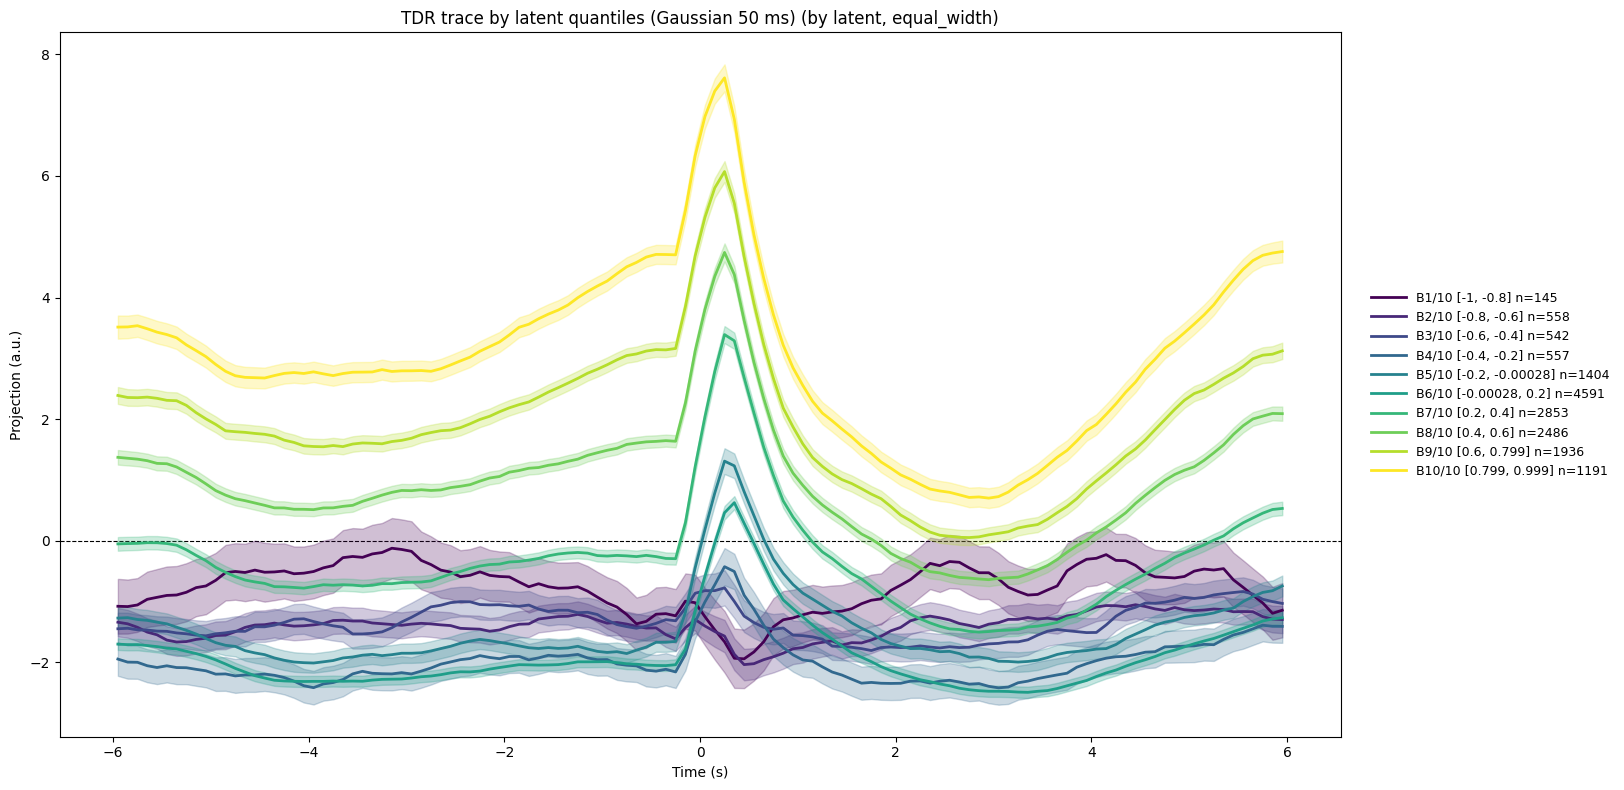

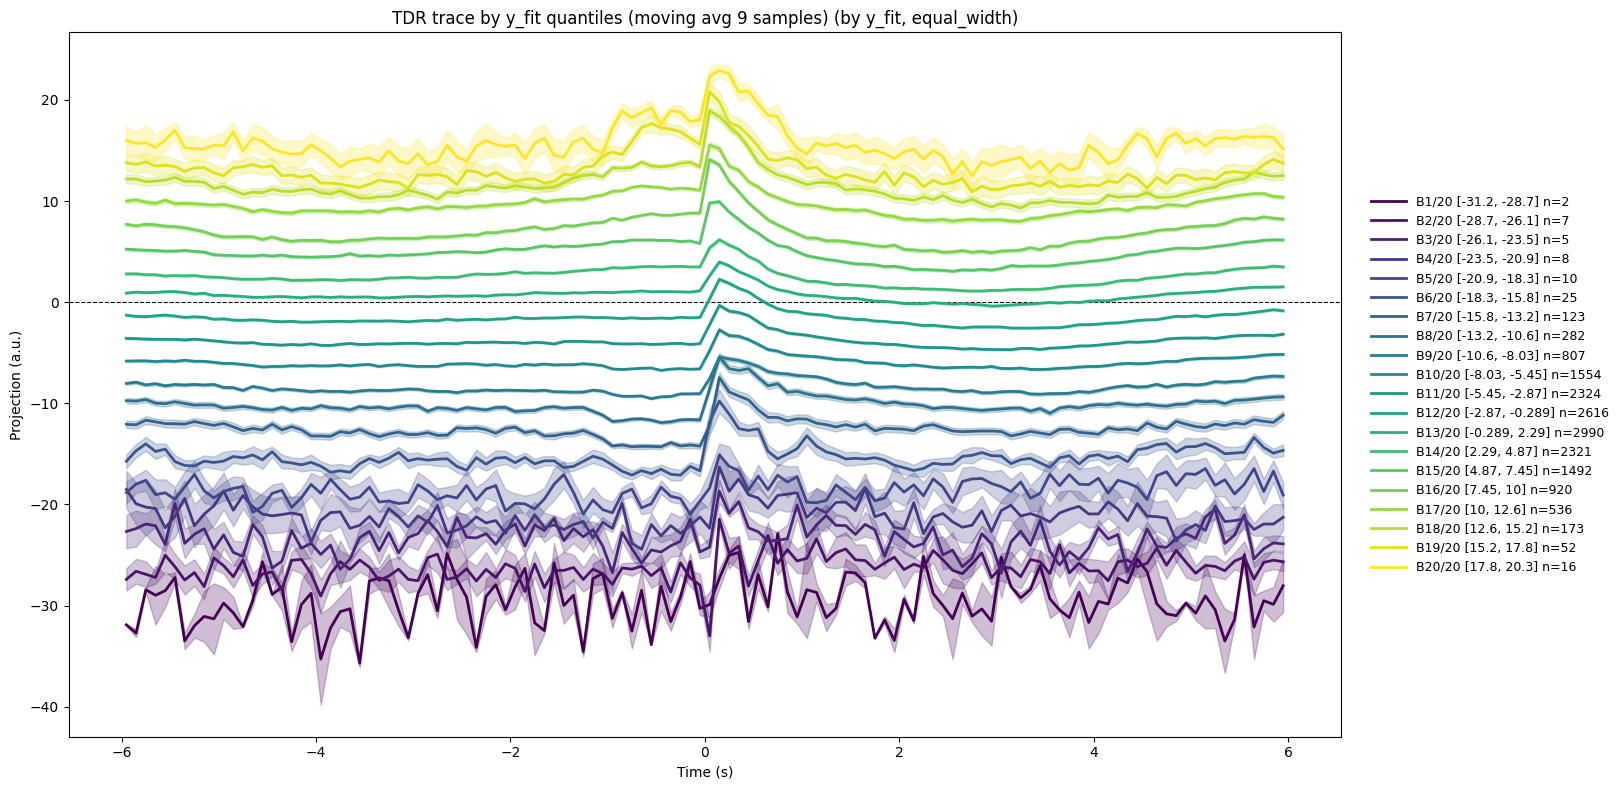

In [7]:
# Get outputs
#Y = ds["projection_trace"]           # (n_trials, n_timepoints)
#y_fit = ds["projection"].values             # (n_trials,)
#latent_inc = ds["latent"].values 
t = ds["time"].values           # (n_timepoints,)


# 1) Gaussian smoothing with sigma = 50 ms before averaging
plot_tdr_trace_by_quantile(
    Y, t, latent=latent_inc, n_quantiles=10,
    group_by="latent", ci="sem", show_trials=False,
    min_traces_per_bin=1,
    smooth={"method":"moving", "window":5, "unit":"samples"},
    title="TDR trace by latent quantiles (Gaussian 50 ms)"
)

# 2) Moving-average smoothing with a 9-sample window
plot_tdr_trace_by_quantile(
    Y, t, latent=latent_inc_z, n_quantiles=20,
    y_fit=y_fit, group_by="y_fit", ci="sem",
    smooth={"method":"moving", "window":1, "unit":"samples"},
    title="TDR trace by y_fit quantiles (moving avg 9 samples)"
)
